## Activation Function 

In [ ]:
# install tensorFlow
# pip install tensorflow

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

from sklearn.metrics import accuracy_score


C:\Users\angaj\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training linear model...
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
Accuracy (linear): 0.86
Training ReLU model...
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
Accuracy (ReLU): 0.98

Visualizing decision boundaries...
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


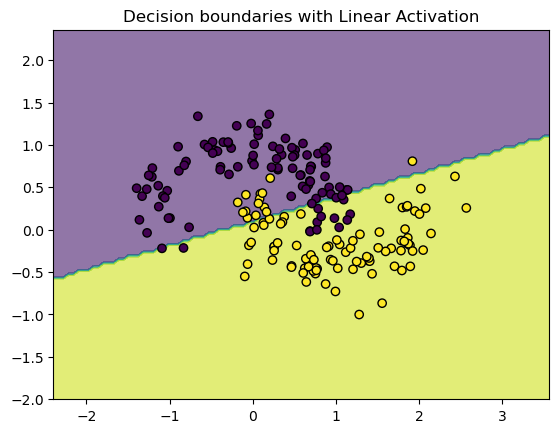

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


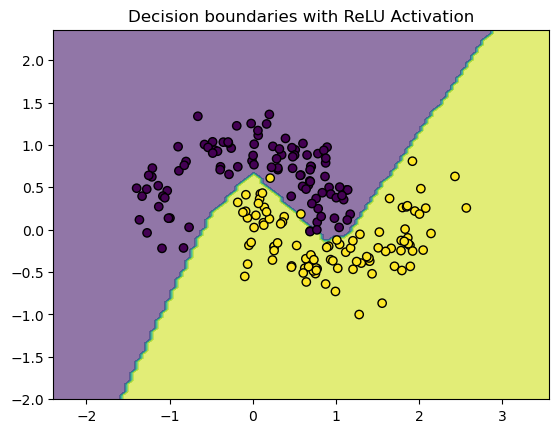

In [22]:
# Generate dataset
x, y = make_moons(n_samples=1000, noise=0.2, random_state=42)
y = y.reshape(-1, 1)

# Train-test split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Linear model
def build_linear_model():
    model = Sequential([
        Dense(4, activation='linear', input_dim=2),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=Adam(learning_rate=0.01),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

# ReLU model
def build_relu_model():
    model = Sequential([
        Dense(4, activation='relu', input_dim=2),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=Adam(learning_rate=0.01),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

# Train & evaluate
def train_and_evaluate(model, x_train, x_test, y_train, y_test, epochs=50, batch_size=32):
    model.fit(x_train, y_train, epochs=epochs, batch_size=batch_size, verbose=0)
    y_pred = (model.predict(x_test) > 0.5).astype(int)
    accuracy = accuracy_score(y_test, y_pred)
    return accuracy, y_pred

# Initialize models
linear_model = build_linear_model()
relu_model = build_relu_model()

# Train linear
print("Training linear model...")
linear_accuracy, _ = train_and_evaluate(linear_model, x_train, x_test, y_train, y_test)
print(f"Accuracy (linear): {linear_accuracy}")

# Train relu
print("Training ReLU model...")
relu_accuracy, _ = train_and_evaluate(relu_model, x_train, x_test, y_train, y_test)
print(f"Accuracy (ReLU): {relu_accuracy}")

# Decision boundary plot
def plot_decision_boundary(model, x, y, title):
    x_min, x_max = x[:, 0].min() - 1, x[:, 0].max() + 1
    y_min, y_max = x[:, 1].min() - 1, x[:, 1].max() + 1

    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                         np.linspace(y_min, y_max, 100))

    grid = np.c_[xx.ravel(), yy.ravel()]
    z = model.predict(grid)
    z = (z > 0.5).astype(int).reshape(xx.shape)

    plt.contourf(xx, yy, z, alpha=0.6)
    plt.scatter(x[:, 0], x[:, 1], c=y.flatten(), edgecolor='k')
    plt.title(title)
    plt.show()

# Plot
print("\nVisualizing decision boundaries...")
plot_decision_boundary(linear_model, x_test, y_test, "Decision boundaries with Linear Activation")
plot_decision_boundary(relu_model, x_test, y_test, "Decision boundaries with ReLU Activation")